# 02 - Exploratory Data Analysis (EDA)
**Metro Traffic Flow Prediction - Statistical & Visual Exploration**

This notebook analyzes distributions, correlations, temporal patterns, and operational impacts on metro traffic flow.

---
### 1. Descriptive Statistics

In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
%pip install matplotlib

import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig_dir = Path.cwd().resolve()
if fig_dir.name == "notebooks":
    fig_dir = fig_dir.parent
fig_dir = fig_dir / "outputs" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

data_path = fig_dir.parent.parent / "data" / "raw" / "metro_traffic_dataset_10000.csv"
if not data_path.exists():
    data_path = fig_dir.parent.parent / "01_Dataset" / "cleaned_dataset.csv"

df = pd.read_csv(data_path)
df.describe().T

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Revanth Reddy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Revanth Reddy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


,count,mean,std,min,25%,50%,75%,max
Station_ID,10000.0,15.454400,8.612917,1.00,8.0000,15.000,23.00000,30.00
Line_ID,10000.0,2.987500,1.410866,1.00,2.0000,3.000,4.00000,5.00
Train_ID,10000.0,139.754700,23.166998,100.00,120.0000,140.000,159.00000,180.00
Hour,10000.0,11.867000,6.925667,0.00,5.9375,11.750,17.75000,23.75
Day_of_Week,10000.0,3.014000,2.001551,0.00,1.0000,3.000,5.00000,6.00
Weekend_Flag,10000.0,0.288000,0.452854,0.00,0.0000,0.000,1.00000,1.00
Holiday_Flag,10000.0,0.037200,0.189261,0.00,0.0000,0.000,0.00000,1.00
Special_Event_Flag,10000.0,0.037000,0.188771,0.00,0.0000,0.000,0.00000,1.00
Peak_Hour_Flag,10000.0,0.271200,0.444601,0.00,0.0000,0.000,1.00000,1.00
Passenger_Count,10000.0,202.393500,66.134477,20.00,154.0000,188.000,247.00000,437.00


---
### 2. Target Variable Distribution
Visualizing the distribution of `Traffic_Flow_Target` via histogram, KDE, and boxplot.

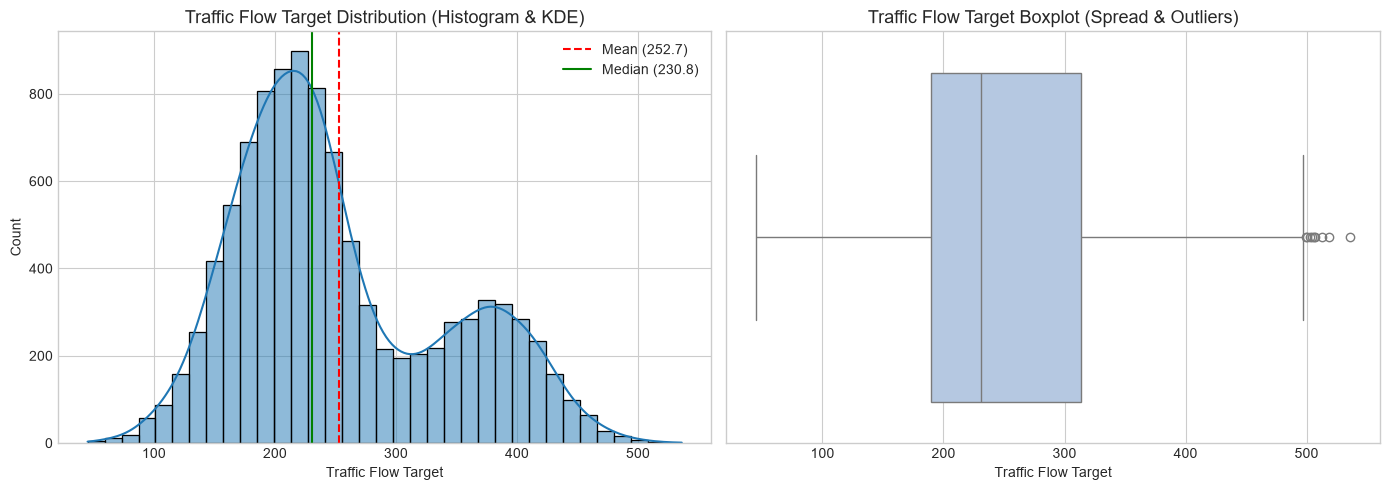

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram & KDE
sns.histplot(df["Traffic_Flow_Target"], kde=True, color="#1f77b4", ax=axes[0], bins=35)
axes[0].axvline(df["Traffic_Flow_Target"].mean(), color="red", linestyle="--", label=f"Mean ({df['Traffic_Flow_Target'].mean():.1f})")
axes[0].axvline(df["Traffic_Flow_Target"].median(), color="green", linestyle="-", label=f"Median ({df['Traffic_Flow_Target'].median():.1f})")
axes[0].set_title("Traffic Flow Target Distribution (Histogram & KDE)", fontsize=13)
axes[0].set_xlabel("Traffic Flow Target")
axes[0].legend()

# Boxplot
sns.boxplot(x=df["Traffic_Flow_Target"], color="#aec7e8", ax=axes[1])
axes[1].set_title("Traffic Flow Target Boxplot (Spread & Outliers)", fontsize=13)
axes[1].set_xlabel("Traffic Flow Target")

plt.tight_layout()
plt.savefig(fig_dir / "eda_traffic_distribution.png", dpi=300)
plt.show()

* **Interpretation:** The traffic flow shows a smooth bimodal / right-leaning spread, driven by off-peak hours vs heavy rush-hour transit spikes.

---
### 3. Key Feature Distributions

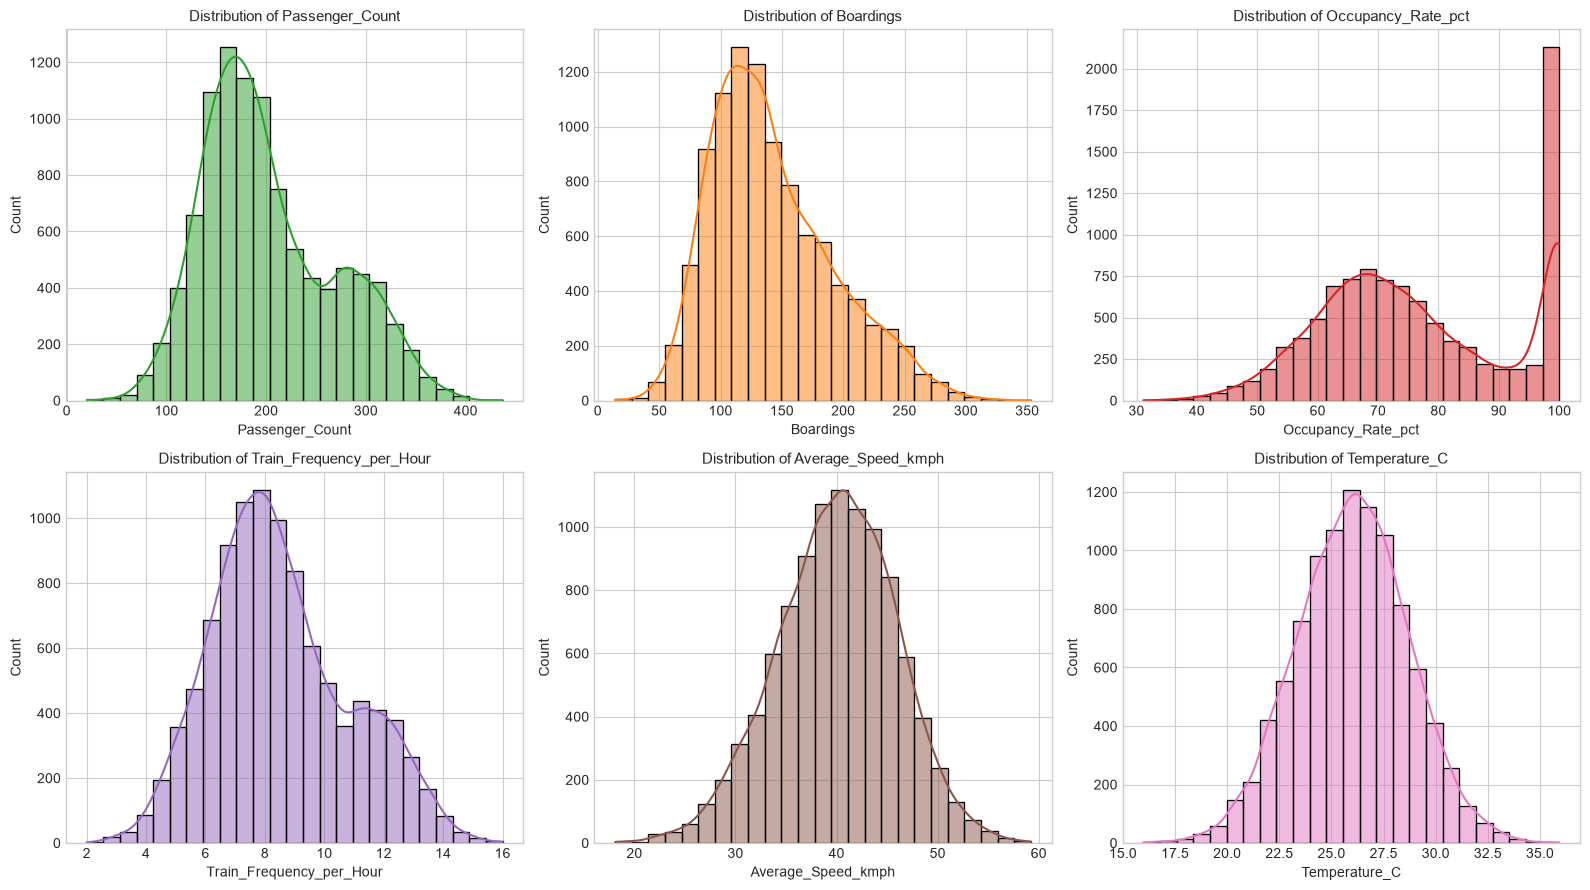

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
features = ["Passenger_Count", "Boardings", "Occupancy_Rate_pct", "Train_Frequency_per_Hour", "Average_Speed_kmph", "Temperature_C"]
colors = ["#2ca02c", "#ff7f0e", "#d62728", "#9467bd", "#8c564b", "#e377c2"]

for i, feat in enumerate(features):
    r, c = i // 3, i % 3
    sns.histplot(df[feat], kde=True, ax=axes[r, c], color=colors[i], bins=25)
    axes[r, c].set_title(f"Distribution of {feat}", fontsize=11)

plt.tight_layout()
plt.savefig(fig_dir / "eda_key_feature_distributions.png", dpi=300)
plt.show()

---
### 4. Correlation Analysis
Identifying features with the strongest linear association with `Traffic_Flow_Target`.

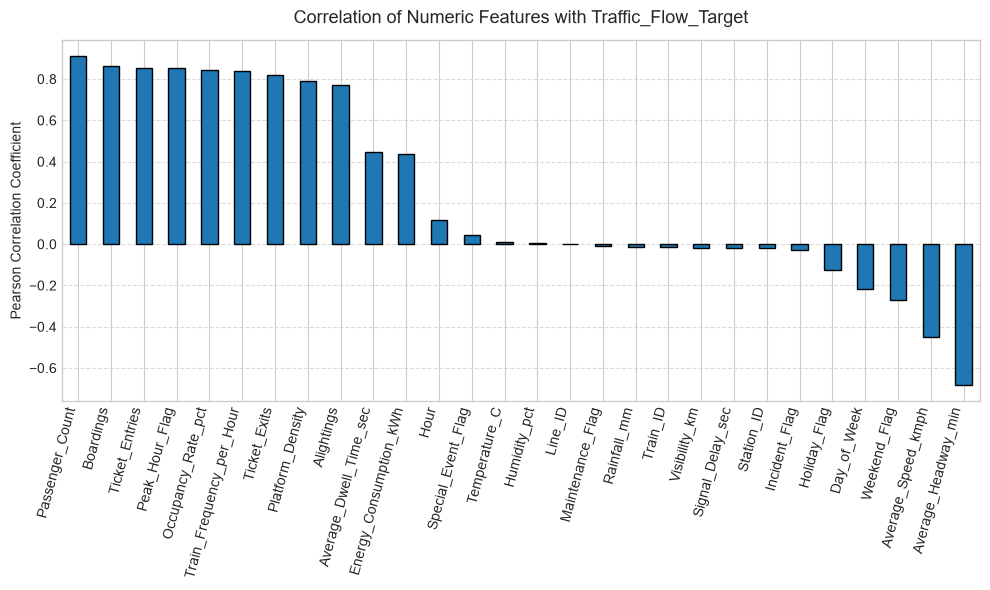

Top 8 Correlated Features with Traffic Flow Target:
Traffic_Flow_Target         1.000000
Passenger_Count             0.910482
Boardings                   0.861553
Ticket_Entries              0.853031
Peak_Hour_Flag              0.852725
Occupancy_Rate_pct          0.845647
Train_Frequency_per_Hour    0.837687
Ticket_Exits                0.817373
Platform_Density            0.792882
Name: Traffic_Flow_Target, dtype: float64


In [11]:
num_df = df.select_dtypes(include=[np.number])
corrs = num_df.corr()["Traffic_Flow_Target"].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
corrs.drop("Traffic_Flow_Target").plot(kind="bar", color="#1f77b4", edgecolor="black")
plt.title("Correlation of Numeric Features with Traffic_Flow_Target", fontsize=13, pad=12)
plt.ylabel("Pearson Correlation Coefficient")
plt.xticks(rotation=75, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(fig_dir / "eda_correlation_bars.png", dpi=300)
plt.show()

print("Top 8 Correlated Features with Traffic Flow Target:")
print(corrs.head(9))

* **Interpretation:** `Passenger_Count` (0.91), `Boardings` (0.86), `Peak_Hour_Flag` (0.85), `Occupancy_Rate_pct` (0.85), and `Train_Frequency_per_Hour` (0.84) are the paramount predictors of traffic flow.

---
### 5. Temporal Patterns: Hourly & Weekly Dynamics

C:\Users\Revanth Reddy\AppData\Local\Temp\ipykernel_23220\1130206445.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_day, x="Day_Name", y="Traffic_Flow_Target", ax=axes[1], order=order, palette="Blues_d")


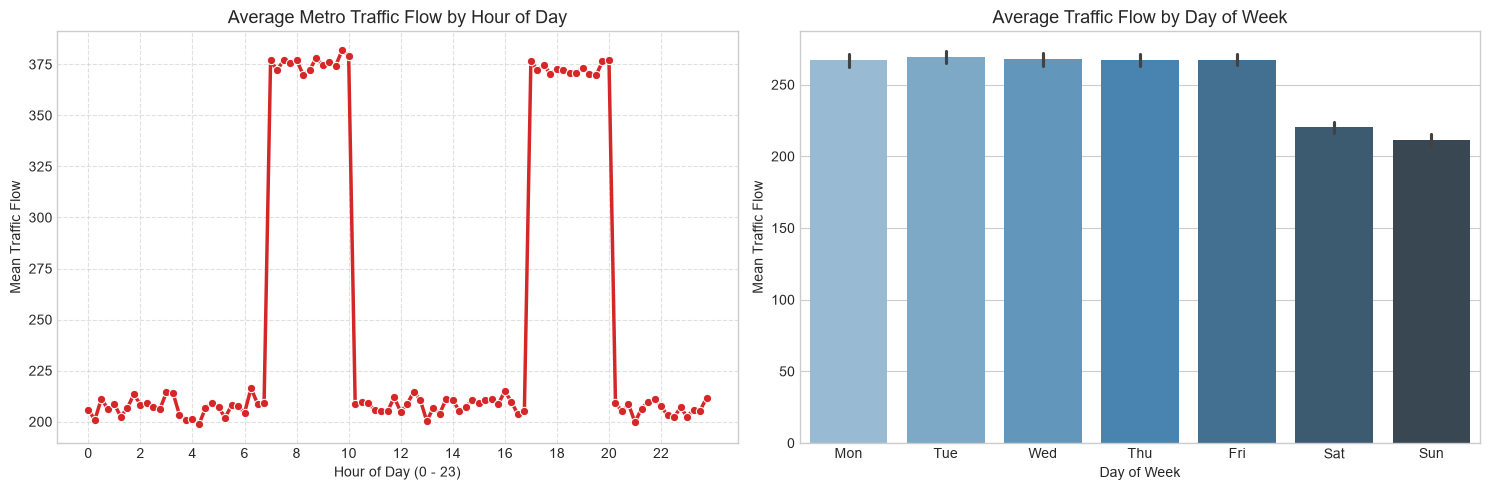

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Hourly Trend
hourly = df.groupby("Hour")["Traffic_Flow_Target"].mean().reset_index()
sns.lineplot(data=hourly, x="Hour", y="Traffic_Flow_Target", ax=axes[0], marker="o", color="#d62728", lw=2.5)
axes[0].set_title("Average Metro Traffic Flow by Hour of Day", fontsize=13)
axes[0].set_xlabel("Hour of Day (0 - 23)")
axes[0].set_ylabel("Mean Traffic Flow")
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, linestyle="--", alpha=0.6)

# Day of Week Trend
day_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
df_day = df.copy()
df_day["Day_Name"] = df_day["Day_of_Week"].map(day_map)
order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
sns.barplot(data=df_day, x="Day_Name", y="Traffic_Flow_Target", ax=axes[1], order=order, palette="Blues_d")
axes[1].set_title("Average Traffic Flow by Day of Week", fontsize=13)
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Mean Traffic Flow")

plt.tight_layout()
plt.savefig(fig_dir / "eda_temporal_patterns.png", dpi=300)
plt.show()

---
### Key Observations from EDA:
1. **Prominent Rush Hour Peaks:** Traffic flow exhibits distinct dual daily peaks: Morning Rush (07:00 - 09:30) and Evening Rush (17:00 - 19:30).
2. **Weekday Demand:** Weekday passenger demand is significantly higher than weekends.
3. **Core Predictive Drivers:** Direct passenger engagement features (`Passenger_Count`, `Boardings`, `Occupancy_Rate_pct`) exhibit correlations exceeding 0.85 with the target.